In [1]:
import numpy as np
import pandas as pd 
import random as rand 
import twang as tw 
import matplotlib.pyplot as plt
import seaborn as sns 

In [ ]:
# importação dos sets de treino e de teste preparados anteriormente
# com as variáveis balanceadas na proporção ("non_purchase")4:1("purchase")
# as variáveis de interesse foram preparadas anteriormente, conforme descrito na referência 
treino = pd.read_csv("set_treino.csv")
treino.drop("Unnamed: 0", axis = 1, inplace = True)
teste = pd.read_csv("set_teste.csv")
teste.drop("Unnamed: 0", axis = 1, inplace = True)

In [3]:
# contrução do modelo de classificação "Random Forest"
# para cada árvore de decisão, o modelo sorteia len(treino) variáveis do teste de treino, com substituíção
# isso permite que observações sejam selecionadas mais de uma vez
# cerca de 63% das observações são analisadas em cada árvore de decisão, o restante é contituído de observações repetidas 
# ao final do ciclo são obtidas 100 árvores de decisão, cada uma treinada com 63% dos dados
florest = list()
for i in range(0,100):
    temp_tree = np.random.choice(a = treino.index, size = len(treino), replace = True)
    ramdom_samples = treino.iloc[temp_tree]
    tree = tw.treeFunc(ramdom_samples, "purchase", "purchase")
    florest.append(tree)

In [4]:
# visualização da "carinha" da árvore obtida


# 5 listas criadas, que irão armazenar os seguintes parâmetros obtidos em cada árvore 
# deep_list: profundidade máxima de cada árvore 
# nodes_list: quantidade de nós e folhas em cada árvore 
# top_proportion_list: melhor proporção de amostras positivas em casa árvore ( com r >= 200)
# n_samples: quantidade de amostras na folha com melhor proporção 
# n_positives: quantidade de amostras positivas na folha com melhor proporção 

deep_list = list()
nodes_list = list()
top_proportion_list = list()
n_samples = list()
n_positives = list()

for i in florest:
    deep_list.append(tw.deepTree(i))
    nodes_list.append(tw.totalNodes(i))
    top_proportion = tw.pathSave(i)
    top_proportion_list.append(top_proportion[0])
    n_samples.append(top_proportion[3])
    n_positives.append(top_proportion[2])

lista_geral = [deep_list, nodes_list, top_proportion_list, n_samples, n_positives]

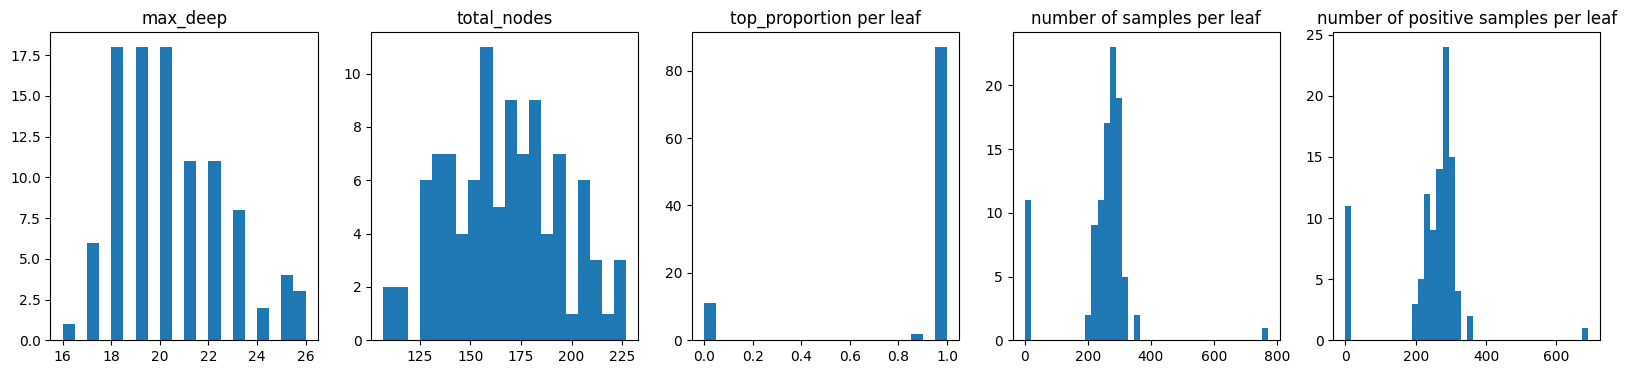

In [5]:
# plot dos histogramas das listas descritas acima 

figura, axis = plt.subplots(1, 5, figsize = (20,4))
axis[0].hist(deep_list, bins = 20)
axis[0].set_title("max_deep")
axis[1].hist(nodes_list, bins = 20)
axis[1].set_title("total_nodes")
axis[2].hist(top_proportion_list, bins = 20)
axis[2].set_title("top_proportion per leaf")
axis[3].hist(n_samples, bins = 40)
axis[3].set_title("number of samples per leaf")
axis[4].hist(n_positives, bins = 40)
axis[4].set_title("number of positive samples per leaf")

plt.show()

In [6]:
# comando para calcular a importancia de cada variável analisada
# a importância é calculada a partir do redução do Gini no nó em que a variável foi determinada como melhor escolha multiplicado pela quantidade de observações presentes no nó 
# foi calculada a importância das variáveis em cada árvore, em seguida o resultado obtido em cada árvore foi somado e normalizado 
importance_dict = {c: 0 for c in treino.columns}
del importance_dict["purchase"]
for i in florest:
    list_temp = tw.importance(i)
    for j in list_temp:
        importance_dict[j[0]] = importance_dict[j[0]] + j[1]*j[4]

list_variables = [ c for c in importance_dict]
list_importance = [importance_dict[c] for c in importance_dict]
importance_norm = [i/sum(list_importance) for i in list_importance]

df_importance_florest = pd.DataFrame({"feature": list_variables, "importance": list_importance, "importance_norm": importance_norm})
df_importance_florest.sort_values(by = "importance_norm", inplace = True)

In [ ]:
# calcula da probabilidade das amostras de teste se classificarem como "purchase" , utilizando o modelo Random Forest 
# cada amostra do set de teste é submetida a todas as árvores de decisão do modelo, cada árvore de decisão entrega a probabilidade da amostra ser classificada como "purchase"
# para cada amostra, é calculada a média das probabilidades obtidas em cada árvore do modelo 
predict_list = []
for i in teste.index:
    prediction = 0
    for j in florest:
        prediction = prediction + tw.predictFunc(j, teste.iloc[i])
    predict_list.append(prediction/len(florest))

teste["pred_florest"] = predict_list


In [ ]:
# cálculo de uma árvore de decisão tradicional 
# modelo análogo ao Random Forest, exceto pelos seguintes pontos 
# 1 - O set de treino é usado em sua totalidade, apenas uma vez 
# 2 - Em cada nó, não são sorteadas variáveis para a obtenção do limiar que entrega a maior redução de Gini
#      todas as variáveis e todos os limiares possíveis são calculados em cada nó 
full_tree = tw.full_treeFunc(treino, "purchase", "purchase")

# cálculo da importância de cada variável no modelo de parvore de decisão simples 
# mesmo cálculo utilizado nas árvores do modelo Random Forest 
importance_single = {c: 0 for c in treino.columns}
del importance_single["purchase"]
list_importance_single = tw.importance(full_tree)
for i in list_importance_single:
    importance_single[i[0]] = importance_single[i[0]] + i[1]*i[4]

importance_abs_tree = [importance_single[c] for c in importance_single]
importance_norm_tree = [i/sum(importance_abs_tree) for i in importance_abs_tree]
variables_tree = [c for c in importance_single]

df_importance_tree = pd.DataFrame({"variables": variables_tree, "importance": importance_abs_tree, "importance_norm": importance_norm_tree})
df_importance_tree.sort_values(by = "importance_norm", inplace = True)

# calculo da probabilidade das amostras de teste se classificarem como "purchase"
predict_list_tree = [tw.predictFunc(full_tree, teste.iloc[i]) for i in teste.index]
teste["pred_tree"] = predict_list_tree

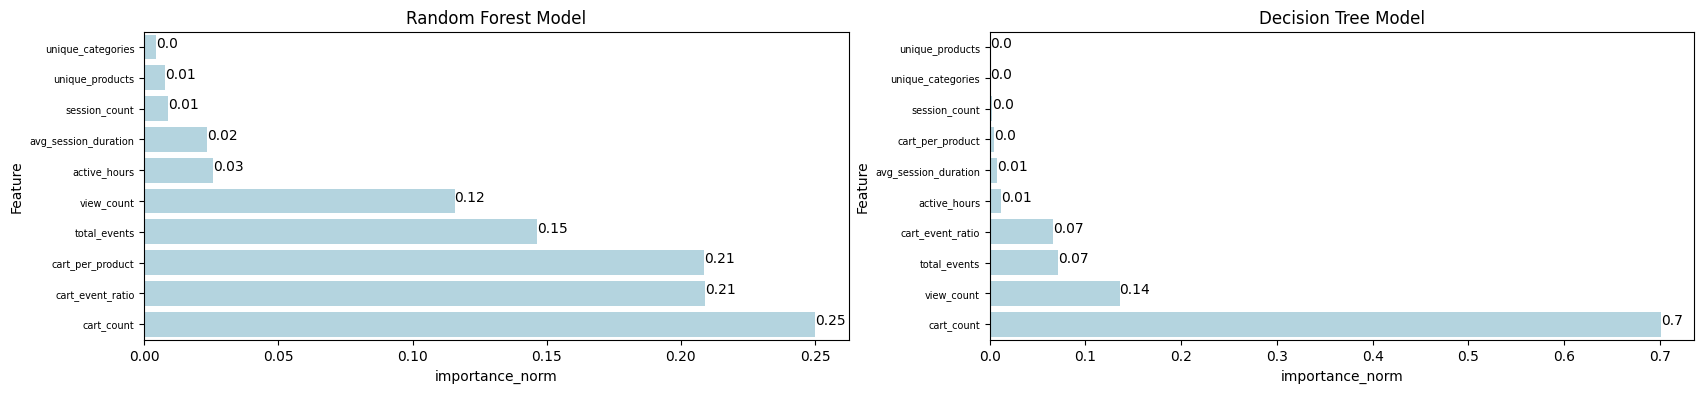

In [ ]:
# comando simples para o plot da importância de cada variável analisada, para os dois modelos 

figura, axis = plt.subplots(1,2, figsize = (20,4))

sns.barplot(data =df_importance_florest, x = "importance_norm", y = "feature" , ax = axis[0], color = "lightblue")
sns.barplot(data = df_importance_tree, x = "importance_norm", y = "variables", ax = axis[1], color = "lightblue")

axis[0].set_yticks(ticks = range(0,len(df_importance_florest)), labels = df_importance_florest["feature"], fontsize = 7)
axis[0].set_ylabel("Feature")
axis[0].set_title("Random Forest Model")
for idx, i in enumerate(df_importance_florest["importance_norm"]):
    axis[0].text(x = i, y = idx, s = round(i,2))
axis[1].set_yticks(ticks = range(0,len(df_importance_tree)), labels = df_importance_tree["variables"], fontsize = 7)
axis[1].set_ylabel("Feature")
axis[1].set_title("Decision Tree Model")
for idx, i in enumerate(df_importance_tree["importance_norm"]):
    axis[1].text(x = i, y = idx, s = round(i,2))


In [ ]:
# função para calcular a matriz de confusão e as figuras de mérito 
# recebe um DataFrame com a classificação real e a probabilidade de cada observação ser classificada como positiva 
# as colunas aonde se encontras as classificações devem ser especificadas no imput 
# o threshold da classificação deve ser especificado 
def confusion(df, variable, variable_ver, threshold):
    df_temp =  df[[variable, variable_ver]].copy()
    df_temp["ver"] = ["purchase" if i > threshold else "non_purchase" for i in df_temp[variable_ver]]
    
    # separação do dataframe em positivo_real e negativo_real 
    positive_side = df_temp[df_temp["purchase"] == "purchase"]
    negative_side = df_temp[df_temp["purchase"] == "non_purchase"]
    
    TP = (positive_side[variable] == positive_side["ver"]).astype(float).sum()
    TN = (negative_side[variable] == negative_side["ver"]).astype(float).sum()
    FP = (negative_side[variable] != negative_side["ver"]).astype(float).sum()
    FN = (positive_side[variable] != positive_side["ver"]).astype(float).sum()
    
    Acuracy = (TP + TN) / (TP + TN + FP + FN)
    Precision = TP / (TP + FP)
    Recall = TP / (TP + FN)
    F1 = (2 * TP) / ((2*TP) + FP + FN)

    df_conf = pd.DataFrame({f"confusion {threshold}": [TP, TN, FP, FN]}, index = ["TP", "TN", "FP", "FN"])
    df_merit = pd.DataFrame({f"merit {threshold}": [Acuracy, Precision, Recall, F1]}, index = ["Acuracy", "Precision", "Recall", "F1"])
    
    # retorna dois dataframes, a matriz de confusão e as figuras de mérito
    return df_conf, df_merit


In [ ]:
# cálculo da matriz de confusão e das figuras de mérito, para os dois modelos, e para diferentes limiares 
conf_florest, merit_florest = confusion(teste, "purchase", "pred_florest", 0.5)
conf_tree, merit_tree = confusion(teste, "purchase", "pred_tree", 0.5)

for i in [0.6, 0.7, 0.8, 0.9, 0.95]:
    conf_florest1, merit_florest1 = confusion(teste, "purchase", "pred_florest", i)
    conf_tree1, merit_tree1 = confusion(teste, "purchase", "pred_tree", i)

    conf_florest = pd.concat([conf_florest, conf_florest1], axis = 1)
    merit_florest = pd.concat([merit_florest, merit_florest1], axis = 1)

    conf_tree = pd.concat([conf_tree, conf_tree1], axis = 1)
    merit_tree = pd.concat([merit_tree, merit_tree1], axis = 1)




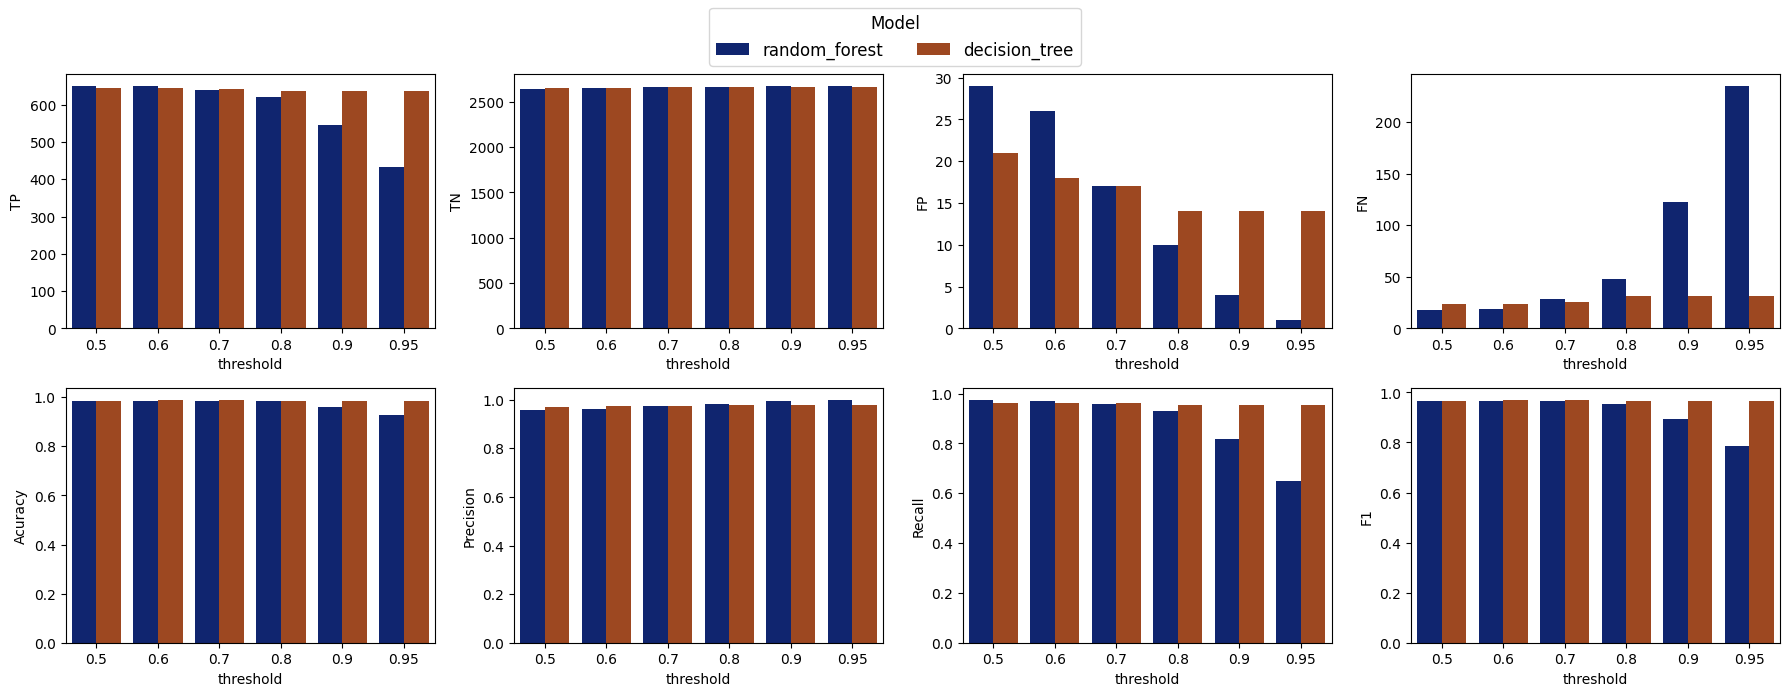

In [60]:
# junção das matrizes de confusão dos dois modelos 
plot_list_conf = conf_florest.index.tolist()
conf_florest_test = conf_florest.T.copy()
conf_florest_test["model"] = "random_forest"
conf_tree_teste  = conf_tree.T.copy()
conf_tree_teste["model"] = "decision_tree"

confusion_matrix = pd.concat([conf_florest_test, conf_tree_teste], axis = 0)
confusion_matrix.reset_index(inplace = True, names = "threshold")
confusion_matrix["threshold"] = confusion_matrix["threshold"].str.removeprefix("confusion ")
confusion_matrix["threshold"] = confusion_matrix["threshold"].astype(float)

# junção das matrizes de figura de mérito para os dois modelos 
plot_list_merit = merit_florest.index.tolist()
merit_florest_test = merit_florest.T.copy()
merit_florest_test["model"] = "random_forest"
merit_tree_test = merit_tree.T.copy()
merit_tree_test["model"] = "decision_tree"

merit_matrix = pd.concat([merit_florest_test, merit_tree_test], axis = 0)
merit_matrix.reset_index(inplace = True, names= "threshold")
merit_matrix["threshold"] = merit_matrix["threshold"].str.removeprefix("merit ")
merit_matrix["threshold"] = merit_matrix["threshold"].astype(float)

# plot dos resultados de validação dos modelos 
figura, axis = plt.subplots(2,4, figsize = (18,7))
for i in range(0,4):
    sns.barplot(data = confusion_matrix, x = "threshold", y = plot_list_conf[i], hue = "model", ax = axis[0,i], palette= "dark")
    sns.barplot(data = merit_matrix, x = "threshold", y = plot_list_merit[i], hue = "model", ax = axis[1,i], palette= "dark")

handles, labels = axis[0,0].get_legend_handles_labels()
for ax in axis.flatten():
    ax.get_legend().remove()
figura.legend(handles, labels, loc="upper center", ncol=len(labels), fontsize=12, title="Model", title_fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.92])